In [1]:
from calculate_return_rate import *
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
from utils import *

In [2]:
ALGORITHMS_OF_INTEREST = ['AugmentedAEO', 'HI_WOA', 'OriginalAEO', 'ModifiedAEO', 'OriginalWOA', 'OriginalDE', 'JADE', 'OriginalSHADE']
INPUT_DIR = "data/clustering_features_20_algorithms_kmeans"
OUTPUT_DIR = "figures_revisiting/comparison"

In [3]:
def visualize_2_problems(problem1, problem2, dimension, save=False):
    input_dir = f'{INPUT_DIR}/cluster_distributions/dim_{dimension}'
    output_dir = f'{OUTPUT_DIR}/dim_{dimension}'
    os.makedirs(output_dir, exist_ok=True)
    history = get_all_problems_revisiting_history(input_dir, ALGORITHMS_OF_INTEREST) 
    matrix1 = pairwise_revisit_matrix(input_dir, ALGORITHMS_OF_INTEREST,specified_problem=problem1, history=history)
    matrix2 = pairwise_revisit_matrix(input_dir, ALGORITHMS_OF_INTEREST, specified_problem=problem2, history=history)
    sns.set_theme(font_scale=0.7)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for ax, matrix, problem in zip(axes, [matrix1, matrix2], [problem1, problem2]):
        sns.heatmap(matrix, annot=True, fmt='.2f', cmap='YlGnBu',
                    vmin=0.0, vmax=1.0, ax=ax)
        ax.set_title(f'Shared Revisit Rate — {problem}', pad=12)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    fig.suptitle(f'Shared Revisit Rate Comparison (dim={dimension})', fontsize=13, y=1.02)
    plt.tight_layout()
    
    if save:
        plt.savefig(f'{output_dir}/comparison_{problem1}_vs_{problem2}.pdf', bbox_inches='tight', pad_inches=0.2)
    
    sns.set_theme(font_scale=1)
    plt.show()
    plt.close()

100%|██████████| 120/120 [00:14<00:00,  8.12it/s]


               AugmentedAEO    HI_WOA      JADE  ModifiedAEO  OriginalAEO  \
AugmentedAEO       1.000000  0.384615  0.263158     0.333333     0.416667   
HI_WOA             0.384615  1.000000  0.454545     0.647059     0.562500   
JADE               0.263158  0.454545  1.000000     0.619048     0.631579   
ModifiedAEO        0.333333  0.647059  0.619048     1.000000     0.687500   
OriginalAEO        0.416667  0.562500  0.631579     0.687500     1.000000   
OriginalDE         0.200000  0.454545  0.652174     0.700000     0.476190   
OriginalSHADE      0.238095  0.478261  0.739130     0.636364     0.500000   
OriginalWOA        0.294118  0.578947  0.636364     0.777778     0.611111   

               OriginalDE  OriginalSHADE  OriginalWOA  
AugmentedAEO     0.200000       0.238095     0.294118  
HI_WOA           0.454545       0.478261     0.578947  
JADE             0.652174       0.739130     0.636364  
ModifiedAEO      0.700000       0.636364     0.777778  
OriginalAEO      0.476190 

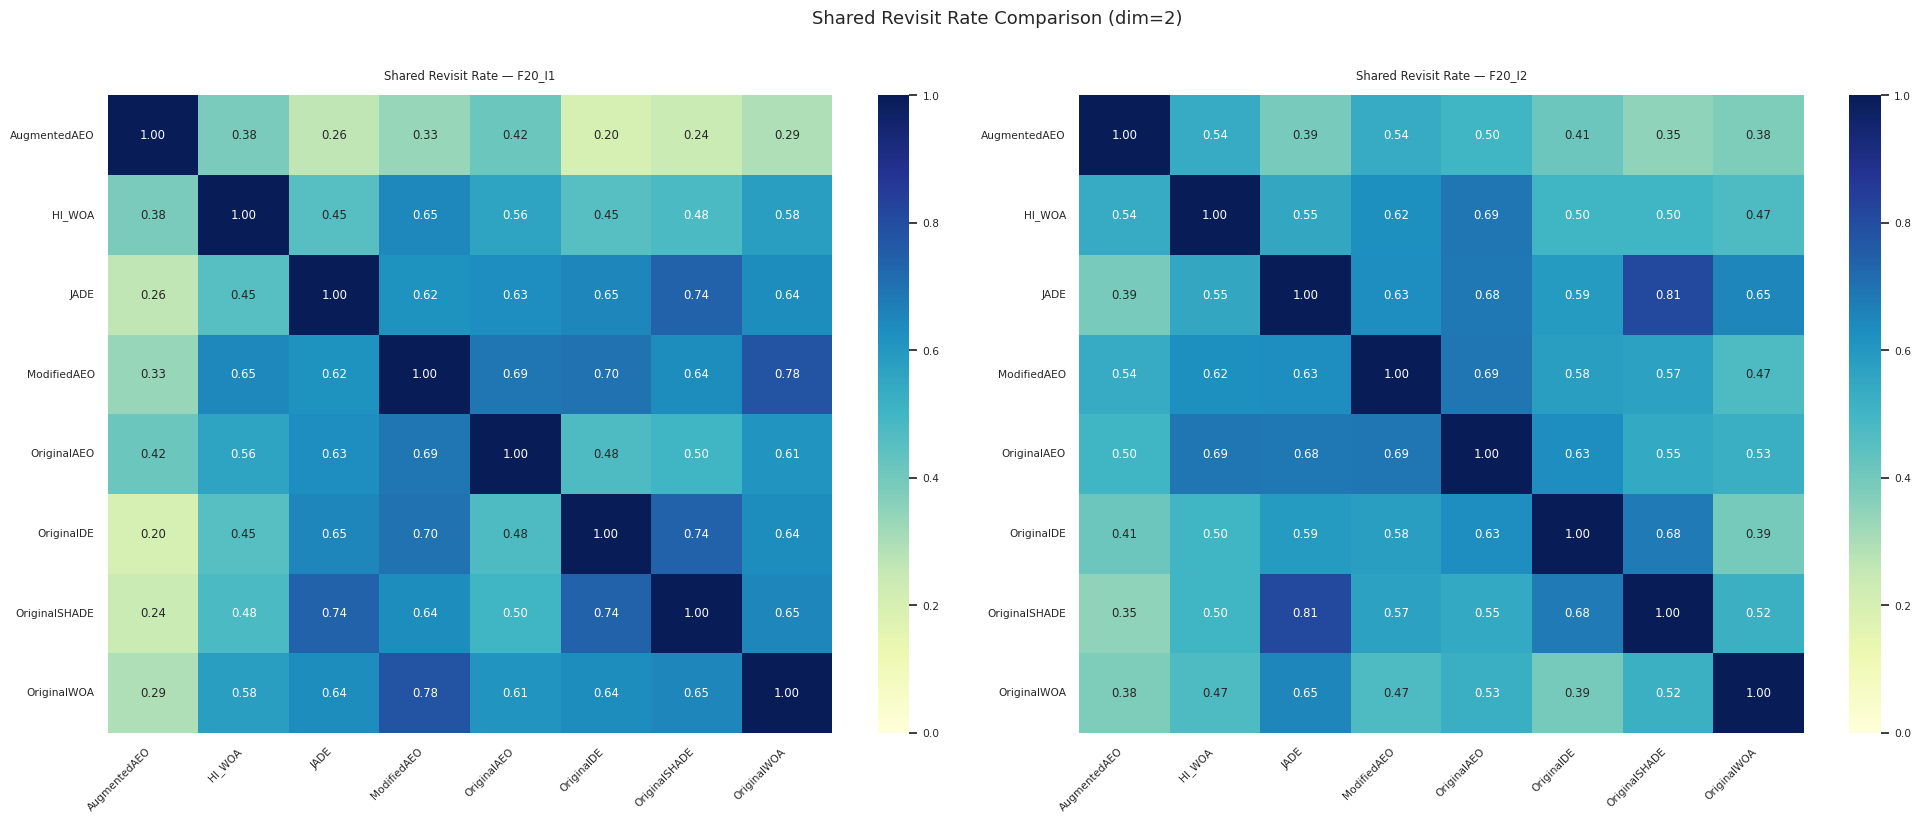

In [4]:
visualize_2_problems("F20_I1", "F20_I2", 2)